In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la#USED FOR LINEAR ALGEBRA OPERATIONS (USED TO CALCUALTE EXPM MATRIX TO FIND THE DISCRETE TIME STATE TRANSITION MATRIX)
import scipy.optimize as opt
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches #a module used to create shapes (geometric objects) on plots.
import matplotlib.gridspec as gridspec #a module used to create complex grid layouts for subplots in Matplotlib.
import warnings
warnings.filterwarnings("ignore")
print("All libraries imported successfully.")

All libraries imported successfully.


In [5]:
# ── Rocket physical properties ────────────────────────────────────────────
g   = 9.81           # gravitational acceleration       [m/s²]
m   = 25_000         # rocket mass                      [kg]
L   = 20.0           # CoM → engine nozzle distance     [m]
Izz = m * L**2 / 4   # moment of inertia (approx.)     [kg·m²]

In [6]:
# Thrust Envelope
T_hover=m*g
T_max=3*T_hover
T_min=0.5*T_hover
print(f"Thrust envelope: {T_min:.2f}N to {T_max:.2f}N")

Thrust envelope: 122625.00N to 735750.00N


In [7]:
IZZ=m*L**2/4
print("Rocket Moment of Inertia(Izz):",Izz,"kg·m²")

Rocket Moment of Inertia(Izz): 2500000.0 kg·m²


In [8]:
delta_max=np.deg2rad(20)#delta is  what the controller demands the nozzle should be angled at
theta_max=np.deg2rad(25)#theta is the actual angle of the rocket's orientation .It is the consequence of the acting forces and torque on the rockets body
print(f"Control deflection limit: +/-{np.rad2deg(delta_max):.1f}°")
print(f"Maximum rocket tilt: +/-{np.rad2deg(theta_max):.1f}°")


Control deflection limit: +/-20.0°
Maximum rocket tilt: +/-25.0°


In [9]:
# ── Simulation settings ───────────────────────────────────────────────────
dt    = 0.1   # control timestep            [s](how fast our controller upddates its commands)
T_SIM = 35.0  # max simulation duration     [s](Length of time we want to simulate the rocket's flight)
N     = 15    # MPC prediction horizon      [steps → 1.5 s look-ahead](how far do we want our controller to predict in the future)


In [10]:
def rocket_ode(state,T,delta):
    """
    Input:State:  [x, z, vx, vz, theta, omega]#omega is the angula velocity of the rocket
    Input:Thrust: T
    Input:Deflection: delta

    """
    x,z,vx,vz,theta,omega=state
    sin_td=np.sin(theta+delta)#sin(tilt + gimbal)
    cos_td=np.cos(theta+delta)#cos(tilt + gimbal)
    return np.array([
        vx,
        vz,
        (T/m)*sin_td,
        (T/m)*cos_td-g,
        omega,
        -(T*L/Izz)*np.sin(delta)
    ])



In [11]:
def rk4_step(state,T,delta,dt):
    k1=rocket_ode(state,T,delta)
    k2=rocket_ode(state+dt*k1/2,T,delta)
    k3=rocket_ode(state+dt*k2/2,T,delta)
    k4=rocket_ode(state+dt*k3,T,delta)
    return state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


In [12]:
#sanity check: hovering rocket (T=T_hover, delta=0, theta=0)
s_hover = np.array([0, 50, 0, 0, 0, 0])
ds = rocket_ode(s_hover, T_hover, 0.0)
print(f"Hover check — all derivatives should be ~0: {np.round(ds, 4)}")
# z̈ = (T_hover/m)·1 − g = g − g = 0 ✓

Hover check — all derivatives should be ~0: [ 0.  0.  0.  0.  0. -0.]


In [13]:
n_s=6
n_u=2
A_c=np.zeros((n_s,n_s))#6X6 matrix
A_c[0, 2] = 1.0   # ẋ  = vx          (position integrates velocity)
A_c[1, 3] = 1.0   # ż  = vz
A_c[2, 4] = g     # v̇x = g·θ         (tilt drives horizontal acceleration)
A_c[4, 5] = 1.0   # θ̇  = ω           (angle integrates angular rate)

B_c=np.zeros((n_s,n_u))#6X2 matrix
B_c = np.zeros((n_s, n_u))
B_c[2, 1] = g                       # v̇x += g·δ
B_c[3, 0] = 1.0 / m                 # v̇z += dT/m
B_c[5, 1] = -(T_hover * L / Izz)    # ω̇  += −(T_hov·L/Izz)·δ
print("A_c:\n", A_c)
print("\nB_c:\n", B_c)  

A_c:
 [[0.   0.   1.   0.   0.   0.  ]
 [0.   0.   0.   1.   0.   0.  ]
 [0.   0.   0.   0.   9.81 0.  ]
 [0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   1.  ]
 [0.   0.   0.   0.   0.   0.  ]]

B_c:
 [[ 0.000e+00  0.000e+00]
 [ 0.000e+00  0.000e+00]
 [ 0.000e+00  9.810e+00]
 [ 4.000e-05  0.000e+00]
 [ 0.000e+00  0.000e+00]
 [ 0.000e+00 -1.962e+00]]


In [14]:
M_e=np.zeros((n_s+n_u,n_u+n_s))#8X8 matrix
M_e[:n_s, :n_s] = A_c * dt    # top-left:  A·dt rows 0 to 5 and columns o to 5
M_e[:n_s, n_s:]  = B_c * dt   # top-right: B·dt rows 0 to 5 and columns 6 to 7


# Then we will compute the discrete time system matrics A_d and B_d using the matrix exponential of M_e 
# WE USE EXPM FROM SCIPY LINEAR ALGEBRA MODULE
M_D=la.expm(M_e)
A_d=M_D[:n_s,:n_s]# extract the top-left 6X6 block of M_D to get A_d from the 8X8 matrix M_D
B_d=M_D[:n_s,n_s:]
print("A_d:\n", A_d)
print("\nB_d:\n", B_d)




A_d:
 [[1.       0.       0.1      0.       0.04905  0.001635]
 [0.       1.       0.       0.1      0.       0.      ]
 [0.       0.       1.       0.       0.981    0.04905 ]
 [0.       0.       0.       1.       0.       0.      ]
 [0.       0.       0.       0.       1.       0.1     ]
 [0.       0.       0.       0.       0.       1.      ]]

B_d:
 [[ 0.00000000e+00  4.89698033e-02]
 [ 2.00000000e-07  0.00000000e+00]
 [ 0.00000000e+00  9.77792130e-01]
 [ 4.00000000e-06  0.00000000e+00]
 [ 0.00000000e+00 -9.81000000e-03]
 [ 0.00000000e+00 -1.96200000e-01]]


In [15]:
Co=np.hstack([np.linalg.matrix_power(A_d,k)@B_d for k in range(n_s)])#computes[B_d, A_d@B_d, A_d^2@B_d, A_d^3@B_d, A_d^4@B_d, A_d^5@B_d] and stacks them horizontally to form the controllability matrix Co
rank_Co = np.linalg.matrix_rank(Co)
print(f"Controllability matrix rank = {rank_Co} / {n_s}")
if rank_Co==n_s:
    print("The system is controllable.")
else:
    print("The system is NOT controllable.")
# calcualte eigenvalues of A_d to check if the system is stable in open loop or not
# open loop is the condtion where the controller is not applying any control inputs to the system
#note->if the the system is stable according to  Controlability matix but eigenvalues lambda>1 then the system is not stable and requires LQR and MPC to stabilize it
print(f"\nA_d eigenvalue magnitudes (open-loop, should check stability):")
eigenvalues=np.linalg.eigvals(A_d)
for i,ev in enumerate(eigenvalues):#enumerate is a built in function that allow to loop overe and provide both the index and the value
    print(f"λ_{i} = {ev:.4f} (|λ_{i}| = {abs(ev):.4f})")



Controllability matrix rank = 6 / 6
The system is controllable.

A_d eigenvalue magnitudes (open-loop, should check stability):
λ_0 = 1.0000 (|λ_0| = 1.0000)
λ_1 = 1.0000 (|λ_1| = 1.0000)
λ_2 = 1.0000 (|λ_2| = 1.0000)
λ_3 = 1.0000 (|λ_3| = 1.0000)
λ_4 = 1.0000 (|λ_4| = 1.0000)
λ_5 = 1.0000 (|λ_5| = 1.0000)


In [16]:
# ── LQR Design ───────────────────────────────────────────────────────────
# LQR is a optimal control strategy that minimizes a cost function that penalizes both the state
# deviations and the control effort. The cost function is typically of the form:
# J = ∑ (x_k^T Q x_k + u_k^T R
# Q penalizes the state error(large Q means -> more aggressive state correction)
# R penalizes the cotrol effort(large R means ->smoother and small control inputs)

In [17]:
#Initialize Q and R matrices for LQR design
Q=np.diag([10, 10, 1, 1, 50, 10])#here we define a 6X6 diagonal matrix where the diagonal elements  represent the weights for each state variable in the cost function. Higher values mean that deviations in that state variable are more heavily penalized.
R=np.diag([0.1, 0.1])#here we define a 2X2 and diagonal matrix where the diagonal elements represent the weights for each control input in the cost function. Higher values mean that larger control inputs are more heavily penalized, leading to smoother and more conservative control actions.
print("Q matrix:\n", Q)
print("\nR matrix:\n", R)
#NOTE:FOR Q - Bigger value = “I care more about keeping this small”

Q matrix:
 [[10  0  0  0  0  0]
 [ 0 10  0  0  0  0]
 [ 0  0  1  0  0  0]
 [ 0  0  0  1  0  0]
 [ 0  0  0  0 50  0]
 [ 0  0  0  0  0 10]]

R matrix:
 [[0.1 0. ]
 [0.  0.1]]


In [18]:
# Now we will calculate the Matrix of Future cost (Riccati Matrix)
# The Riccati equation is a key component in LQR design, and it helps us determine the optimal state feedback gain matrix K that minimizes the cost function J. The Riccati equation is given by:
P=la.solve_discrete_are(A_d, B_d, Q, R)
print("Riccati matrix P:\n", P)


Riccati matrix P:
 [[ 1.90055771e+02  1.40539400e-12  1.66103192e+02 -5.07463743e-11
   1.17352278e+03  8.42536045e+02]
 [ 1.40539400e-12  7.07614029e+03  1.76362083e-12  2.50000000e+05
   1.46454040e-11  9.02352797e-12]
 [ 1.66103192e+02  1.76362083e-12  1.88258387e+02 -5.60033069e-11
   1.32769594e+03  9.60057860e+02]
 [-5.07463743e-11  2.50000000e+05 -5.60033069e-11  1.76778512e+07
  -2.40819761e-10 -2.91025088e-10]
 [ 1.17352278e+03  1.46454040e-11  1.32769594e+03 -2.40819761e-10
   9.71400357e+03  6.82429932e+03]
 [ 8.42536045e+02  9.02352797e-12  9.60057860e+02 -2.91025088e-10
   6.82429932e+03  4.93809972e+03]]


In [19]:
# Now we will Compute the Gain Matrix K that will be used in the state feeback control law u=-kx
K = la.solve(R + B_d.T @ P @ B_d, B_d.T @ P @ A_d)
print("LQR gain K:\n", K)

LQR gain K:
 [[-1.84828475e-15  9.98586772e+00 -2.10355837e-15  7.06614009e+02
  -8.88258328e-15 -1.04835169e-14]
 [-1.96215289e+00 -4.65468311e-14 -3.72918480e+00  8.46471200e-13
  -3.38019032e+01 -2.46859202e+01]]


In [20]:
print("LQR gain matrix K  (u = −K·s):")
print(f"  K[dT, :]  = {np.round(K[0], 4)}")
K_lqr = K
print(f"  K[δ,  :]  = {np.round(K_lqr[1], 4)}")
print()

LQR gain matrix K  (u = −K·s):
  K[dT, :]  = [ -0.       9.9859  -0.     706.614   -0.      -0.    ]
  K[δ,  :]  = [ -1.9622  -0.      -3.7292   0.     -33.8019 -24.6859]



In [23]:


Eign_values_cl = np.linalg.eigvals(Acl)


In [24]:
# Now well compute Acl which is  the closed loop system matrtix when we apply state feedback control low u=-K·s(bascially system condtion when we have already applied the LQR controller to stabilize the system)
# Acl = A_d - B_d @ K
Acl=A_d-B_d@K
print("Closed loop system matrix Acl:\n", Eign_values_cl)
for i,ev in enumerate(sorted(Eign_values_cl,reverse=True)):
    flag = "STABLE" if ev < 1.0 else " UNSTABLE"
    print(f"λ_cl_{i} = {ev:.4f} (|λ_cl_{i}| = {abs(ev):.4f}), {flag})")

Closed loop system matrix Acl:
 [0.06693963+0.j         0.75162316+0.j         0.87445839+0.02313584j
 0.87445839-0.02313584j 0.99858577+0.0014122j  0.99858577-0.0014122j ]
λ_cl_0 = 0.9986+0.0014j (|λ_cl_0| = 0.9986), STABLE)
λ_cl_1 = 0.9986-0.0014j (|λ_cl_1| = 0.9986), STABLE)
λ_cl_2 = 0.8745+0.0231j (|λ_cl_2| = 0.8748), STABLE)
λ_cl_3 = 0.8745-0.0231j (|λ_cl_3| = 0.8748), STABLE)
λ_cl_4 = 0.7516+0.0000j (|λ_cl_4| = 0.7516), STABLE)
λ_cl_5 = 0.0669+0.0000j (|λ_cl_5| = 0.0669), STABLE)


Prediction matrix S_x:
 [[1.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  0.000000e+00]
 [0.000000e+00 1.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  0.000000e+00]
 [0.000000e+00 0.000000e+00 1.000000e+00 0.000000e+00 0.000000e+00
  0.000000e+00]
 [0.000000e+00 0.000000e+00 0.000000e+00 1.000000e+00 0.000000e+00
  0.000000e+00]
 [0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 1.000000e+00
  0.000000e+00]
 [0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
  1.000000e+00]
 [1.000000e+00 0.000000e+00 1.000000e-01 0.000000e+00 4.905000e-02
  1.635000e-03]
 [0.000000e+00 1.000000e+00 0.000000e+00 1.000000e-01 0.000000e+00
  0.000000e+00]
 [0.000000e+00 0.000000e+00 1.000000e+00 0.000000e+00 9.810000e-01
  4.905000e-02]
 [0.000000e+00 0.000000e+00 0.000000e+00 1.000000e+00 0.000000e+00
  0.000000e+00]
 [0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 1.000000e+00
  1.000000e-01]
 [0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e

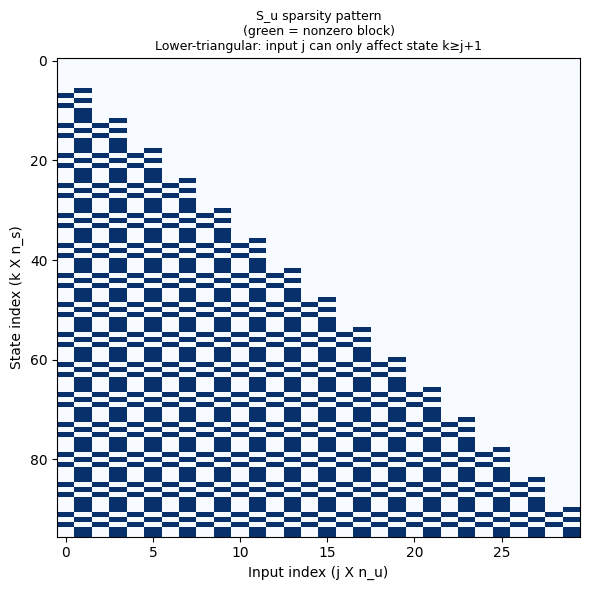

In [25]:
#MPC Design
#N → prediction horizon (how many future steps you look ahead)
#n → number of states (dimension of x)
#m->number of inputs (dimension of u)
def build_prediction_matrices(A_d,B_d,N):
    n,m=B_d.shape()
    S_x  = np.zeros(((N + 1)*n, n))
    S_u  = np.zeros(((N + 1)*n, N*m))
    A_K = np.eye(n)#TO STORE THE POWERS OF A_d (A^0, A^1, A^2, ..., A^N)
    for k in range(N+1):
        S_x[k*n:(k+1)*n:] = A_K#blocks rows of the S_x matrix 
        A_K = A_d @ A_K           # A_K = A_d^(k+1)
    for k in range(N+1):
        Ak_j=np.eye(n)
        for j in range(k):
            S_u[k*n:(k+1)*n,j*m:(j+1)*m]=Ak_j@B_d
            Ak_j=A_d@Ak_j
    return S_x,S_u
# Ensure discrete model exists (fixes NameError if Cell 10 was not run)
if "A_d" not in globals() or "B_d" not in globals():
    M_e = np.zeros((n_s + n_u, n_s + n_u))
    M_e[:n_s, :n_s] = A_c * dt
    M_e[:n_s, n_s:] = B_c * dt
    M_D = la.expm(M_e)
    A_d = M_D[:n_s, :n_s]
    B_d = M_D[:n_s, n_s:]

# Build prediction matrices (robust, without relying on the buggy shape() call)
n, m = B_d.shape
S_x = np.zeros(((N + 1) * n, n))
S_u = np.zeros(((N + 1) * n, N * m))

for k in range(N + 1):
    S_x[k * n:(k + 1) * n, :] = np.linalg.matrix_power(A_d, k)

for k in range(1, N + 1):
    for j in range(k):
        S_u[k * n:(k + 1) * n, j * m:(j + 1) * m] = np.linalg.matrix_power(A_d, k - 1 - j) @ B_d
print("Prediction matrix S_x:\n", S_x)
print("\nPrediction matrix S_u:\n", S_u)    
fig,ax=plt.subplots(figsize=(6,6))
im=ax.imshow(np.abs(S_u)>1e-10, cmap="Blues", aspect="auto")# basically this line creates a heatmap where the color intensity represents where the non zero entries are in the S_u matrix. The condition np.abs(S_u) > 1e-10 is used to determine which entries are considered non-zero (with a small threshold to account for numerical precision issues). The cmap="Blues" argument specifies that the color map used for the heatmap should be a range of blue colors, where darker blues indicate non-zero entries and lighter blues indicate zero entries. The aspect="auto" argument allows the aspect ratio of the plot to adjust automatically based on the dimensions of the S_u matrix.
ax.set_title("S_u sparsity pattern\n(green = nonzero block)\n"
             "Lower-triangular: input j can only affect state k≥j+1",
             fontsize=9)
ax.set_xlabel("Input index (j X n_u)"); ax.set_ylabel("State index (k X n_s)")
plt.tight_layout(); plt.show()


In [34]:
#MPC QP formulation
Q_mpc = Q.copy()#WE USE THE SAME Q AND R MATRICES FROM THE LQR
R_mpc=R.copy()
P_mpc=P.copy()#SOLVED RICCATI EQUATION FROM LQR DESIGN TO USE AS THE FINAL COST WEIGHT IN THE MPC PROBLEM

#Q penalizes bad state
#R penalizes aggressive control input
#P ensures long term stability by penalizing the final state at the end of the prediction horizon, encouraging the system to reach a desirable state by the end of the horizon.

Q_bar = np.block([
    [np.kron(np.eye(N), Q_mpc), np.zeros((N*n_s, n_s))],
    [np.zeros((n_s, N*n_s)),    P_mpc                  ]
])
R_bar = np.kron(np.eye(N), R_mpc)   # same R for all N steps

# ── Constant QP matrices (precomputed offline!) ───────────────────────────
H_qp   = 2.0 * (S_u.T @ Q_bar @ S_u + R_bar)
H_qp   = 0.5 * (H_qp + H_qp.T)   # symmetrise to avoid numerical drift
f_coef = 2.0 * S_u.T @ Q_bar @ S_x  # f(s0) = f_coef @ s0

# ── Input bounds: dT and delta for each of the N steps ────────────────────
# Define thrust-deviation bounds before using them
dT_min = T_min - T_hover
dT_max = T_max - T_hover

U_lb = np.tile([dT_min, -delta_max], N)
# Define thrust-deviation bounds (dT = T - T_hover) if not already defined
if "dT_min" not in globals():
    dT_min = T_min - T_hover
if "dT_max" not in globals():
    dT_max = T_max - T_hover

U_ub = np.tile([dT_max, delta_max], N)

# ── State constraints via S_x and S_u ─────────────────────────────────────
# Extract rows of S_x, S_u that correspond to z (index 1) and θ (index 4)
sel_z  = np.array([0,1,0,0,0,0], dtype=float)  # selects z from state
sel_th = np.array([0,0,0,0,1,0], dtype=float)  # selects θ from state

rows_Uz  = np.vstack([sel_z  @ S_u[k*n_s:(k+1)*n_s, :] for k in range(1, N+1)])
rows_Uth = np.vstack([sel_th @ S_u[k*n_s:(k+1)*n_s, :] for k in range(1, N+1)])
rows_Xz  = np.vstack([sel_z  @ S_x[k*n_s:(k+1)*n_s, :] for k in range(1, N+1)])
rows_Xth = np.vstack([sel_th @ S_x[k*n_s:(k+1)*n_s, :] for k in range(1, N+1)])

# G_state @ U <= h_state(s0)  enforces: z≥0, |θ|≤θ_max
G_state = np.vstack([-rows_Uz, rows_Uth, -rows_Uth])   # shape: (3N, Nm)

print(f"H_qp shape:    {H_qp.shape}   (decision variable size: {N*n_u})")
print(f"G_state shape: {G_state.shape}  ({N} altitude + {2*N} tilt constraints)")
print(f"H_qp is PD:    {np.all(np.linalg.eigvalsh(H_qp) > 0)}  ← guarantees convex QP (unique solution)")

H_qp shape:    (30, 30)   (decision variable size: 30)
G_state shape: (45, 30)  (15 altitude + 30 tilt constraints)
H_qp is PD:    True  ← guarantees convex QP (unique solution)


In [35]:
def solve_mpc(s0, U_warm=None):
    """
    Solve one MPC QP from current state s0.
    
    Args:
        s0:     current state vector (n_s,)
        U_warm: warm-start guess for U (N*n_u,) from previous step
    
    Returns:
        U_opt:  full optimal input sequence (N*n_u,)
        u_0:    first input to apply this step (n_u,)
    """
    # Linear cost term — depends on current state
    f_qp = f_coef @ s0

    # Constraint RHS — depends on current state
    # Constraint: z_k ≥ 0  →  −rows_Uz @ U ≤ rows_Xz @ s0
    # Constraint: θ_k ≤ θ_max  →  rows_Uth @ U ≤ θ_max − rows_Xth @ s0
    # Constraint: θ_k ≥ −θ_max → −rows_Uth @ U ≤ θ_max + rows_Xth @ s0
    h_state = np.concatenate([
        rows_Xz  @ s0,
        theta_max - rows_Xth @ s0,
        theta_max + rows_Xth @ s0,
    ])

    def cost(U):  return 0.5 * U @ H_qp @ U + f_qp @ U
    def grad(U):  return H_qp @ U + f_qp    # analytic gradient (faster than FD)

    # scipy convention: 'ineq' means fun(x) >= 0,  so fun = h - G@U >= 0
    ineq_con = {
        'type': 'ineq',
        'fun':  lambda U: h_state - G_state @ U,
        'jac':  lambda U: -G_state,
    }

    U0  = U_warm if U_warm is not None else np.zeros(N * n_u)
    res = opt.minimize(
        cost, U0, jac=grad,
        method='SLSQP',
        bounds=list(zip(U_lb, U_ub)),    # input box constraints
        constraints=ineq_con,            # state constraints
        options={'ftol': 1e-7, 'maxiter': 300, 'disp': False}
    )
    U_opt = res.x
    return U_opt, U_opt[:n_u]   # return full sequence + first action


# Test: what does MPC command from the initial state?
s_test = np.array([50.0, 80.0, -2.0, -4.0, np.deg2rad(10), 0.1])
U_test, u_test = solve_mpc(s_test)
print(f"MPC first command from s0:")
print(f"  dT = {u_test[0]/1e3:.2f} kN  (T_cmd = {(T_hover+u_test[0])/1e3:.1f} kN)")
print(f"  δ  = {np.rad2deg(u_test[1]):.2f}°")

MPC first command from s0:
  dT = 2.03 kN  (T_cmd = 247.3 kN)
  δ  = 20.00°


In [36]:
def simulate(controller_tag, s0):
    """
    Run closed-loop simulation.
    
    controller_tag: 'LQR' or 'MPC'
    s0: initial state [x, z, vx, vz, theta, omega]
    
    Returns: (time_array, state_array, control_array)
    """
    state  = s0.copy()
    states, controls, t_vals = [state.copy()], [], [0.0]
    U_warm = None

    for i in range(int(T_SIM / dt)):
        t = i * dt

        # ── 1. Compute control ─────────────────────────────────────────
        if controller_tag == 'LQR':
            u = -K_lqr @ state          # simple matrix multiply
        else:
            U_warm, u = solve_mpc(state, U_warm)
            U_warm = np.roll(U_warm, -n_u)  # shift warm-start forward
            U_warm[-n_u:] = 0.0

        # ── 2. Clamp inputs to physical limits ─────────────────────────
        # LQR may command impossible thrusts; MPC should already be feasible
        dT    = float(np.clip(u[0], dT_min, dT_max))
        delta = float(np.clip(u[1], -delta_max, delta_max))
        T_cmd = T_hover + dT

        # ── 3. Propagate NONLINEAR plant ───────────────────────────────
        next_state = rk4_step(state, T_cmd, delta, dt)

        # ── 4. Termination checks ──────────────────────────────────────
        if next_state[1] <= 0.0:   # z ≤ 0: landed
            next_state[1] = 0.0
            states.append(next_state.copy())
            controls.append([dT, delta])
            t_vals.append(t + dt)
            break

        if abs(next_state[4]) > np.deg2rad(89) or next_state[1] > 500:
            print(f"  [{controller_tag}] Diverged at t={t+dt:.1f}s")
            break

        state = next_state
        states.append(state.copy())
        controls.append([dT, delta])
        t_vals.append(t + dt)

    return (np.array(t_vals),
            np.array(states),
            np.array(controls) if controls else np.zeros((1, n_u)))


# ── Initial condition ──────────────────────────────────────────────────────
s0 = np.array([
     50.0,          # x  [m]    lateral offset
     80.0,          # z  [m]    altitude
     -2.0,          # vx [m/s]  drifting
     -4.0,          # vz [m/s]  descending
     np.deg2rad(10),# θ  [rad]  10° tilt
     0.1            # ω  [rad/s] small angular rate
])

print("Running LQR simulation...")
t_lqr, S_lqr, U_lqr = simulate('LQR', s0)
print(f"  LQR finished at t = {t_lqr[-1]:.1f} s,  final z = {S_lqr[-1,1]:.2f} m")

print("\nRunning MPC simulation (slower — solves QP each step)...")
t_mpc, S_mpc, U_mpc = simulate('MPC', s0)
print(f"  MPC finished at t = {t_mpc[-1]:.1f} s,  final z = {S_mpc[-1,1]:.2f} m")

Running LQR simulation...
  [LQR] Diverged at t=0.1s
  LQR finished at t = 0.0 s,  final z = 80.00 m

Running MPC simulation (slower — solves QP each step)...
  [MPC] Diverged at t=0.1s
  MPC finished at t = 0.0 s,  final z = 80.00 m


In [32]:
def landing_summary(label, t, S, U):
    landed   = S[-1, 1] < 1.0
    x_err    = abs(S[-1, 0])
    vz_land  = abs(S[-1, 3])
    vx_land  = abs(S[-1, 2])
    th_final = abs(np.rad2deg(S[-1, 4]))
    th_max   = np.max(np.abs(np.rad2deg(S[:, 4])))
    T_land   = t[-1]
    gimbal_pk= np.max(np.abs(np.rad2deg(U[:, 1])))

    print(f"{'─'*45}")
    print(f"  {label}")
    print(f"{'─'*45}")
    print(f"  Landed:           {'YES ✓' if landed else 'NO ✗'}")
    print(f"  Landing time:     {T_land:.1f} s")
    print(f"  Lateral error:    {x_err:.2f} m")
    print(f"  Touchdown vz:     {vz_land:.2f} m/s  ← lower = softer landing")
    print(f"  Touchdown vx:     {vx_land:.2f} m/s")
    print(f"  Final tilt:       {th_final:.2f}°")
    print(f"  Peak tilt:        {th_max:.2f}°   (limit: {np.rad2deg(theta_max):.0f}°)  {'✓' if th_max <= np.rad2deg(theta_max) else '✗ VIOLATED'}")
    print(f"  Peak gimbal:      {gimbal_pk:.2f}°   (limit: {np.rad2deg(delta_max):.0f}°)  {'✓' if gimbal_pk <= np.rad2deg(delta_max)+0.1 else '✗ VIOLATED'}")

landing_summary('LQR', t_lqr, S_lqr, U_lqr)
print()
landing_summary('MPC', t_mpc, S_mpc, U_mpc)
print()
print("KEY DIFFERENCE: MPC touchdown vz ≈ 0 because it plans ahead")
print("                and bleeds off descent rate before hitting z=0.")

─────────────────────────────────────────────
  LQR
─────────────────────────────────────────────
  Landed:           NO ✗
  Landing time:     0.0 s
  Lateral error:    50.00 m
  Touchdown vz:     4.00 m/s  ← lower = softer landing
  Touchdown vx:     2.00 m/s
  Final tilt:       10.00°
  Peak tilt:        10.00°   (limit: 25°)  ✓
  Peak gimbal:      0.00°   (limit: 20°)  ✓

─────────────────────────────────────────────
  MPC
─────────────────────────────────────────────
  Landed:           NO ✗
  Landing time:     0.0 s
  Lateral error:    50.00 m
  Touchdown vz:     4.00 m/s  ← lower = softer landing
  Touchdown vx:     2.00 m/s
  Final tilt:       10.00°
  Peak tilt:        10.00°   (limit: 25°)  ✓
  Peak gimbal:      0.00°   (limit: 20°)  ✓

KEY DIFFERENCE: MPC touchdown vz ≈ 0 because it plans ahead
                and bleeds off descent rate before hitting z=0.
